In [85]:
#!/usr/bin/env python
# coding: utf-8

In[1]:

In [86]:
#!/usr/bin/env python
# coding: utf-8
import scipy.io
import os
import sys
import numpy as np
import h5py
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import random

Set seeds for reproducibility

In [87]:
random.seed(42)  # For Python's built-in random module
np.random.seed(42)  # For NumPy
torch.manual_seed(42)  # PyTorch
# Optionally, set TensorFlow to deterministic mode for even more reproducibility
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [88]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Ask the user to target the name format

In[2]:

In [141]:
name_format = "SBI_Bz_run15"
print("Note: use results16.mat as train data, results22.m as test data; B only has positive Z values, learning rate 0.0001, batch size 32.")
train_file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # For training
test_file_path = os.path.join('MATLAB_DATA', 'results22.mat')   # For testing

Note: use results16.mat as train data, results22.m as test data; B only has positive Z values, learning rate 0.0001, batch size 32.


In [90]:
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Define the list of files that should be processed as HDF5 files

In[3]:

In [91]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In[4]:

In [92]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In[5]:

In [93]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In[6]:

In [94]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In[7]:

In [95]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In[8]:

In [96]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

File paths for training and testing data

In[9]:

Load and process the training data

In [97]:
print("Loading training data...")
B_MAG_data_train, EDC_MAG_data_train, X_data_train, I_data_train = load_and_process_file(train_file_path)
# Load and process the testing data
print("Loading testing data...")
B_MAG_data_test, EDC_MAG_data_test, X_data_test, I_data_test = load_and_process_file(test_file_path)

Loading training data...
Processing results16.mat as a .mat file...
Loading testing data...
Processing results22.mat as a .mat file...


Data is now loaded and processed.

In[10]:

In [98]:
def resample_and_smooth_data(normalized_data, new_length=1200):
    resampled_data = []
    
    for row in normalized_data:
        original_length = len(row)
        # Define the original x values (relative position in the original data)
        x_original = np.linspace(0, 1, num=original_length)
        
        # Define the new x values (for the desired length)
        x_new = np.linspace(0, 1, num=new_length)
        
        # Use cubic interpolation to resample and smooth
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_row = f(x_new)
        
        resampled_data.append(resampled_row)
    
    return np.array(resampled_data)

In[11]:

In [99]:
means = np.mean(I_data_train, axis=0)
stds= np.std(I_data_train, axis=0)
start_index = 0
end_index = I_data_train.shape[1] - 1

In[12]:

In [100]:
for i in range(I_data_train.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In[13]:

In [101]:
for i in range(I_data_train.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In[14]:

In [102]:
I_data_filtered_train = I_data_train[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
print(f"Data filtered from column {start_index} to {end_index}.")

Data filtered from column 105 to 1097.


Normalize the data

In[15]:

In [103]:
normalized_I_train = (I_data_filtered_train - means_filtered) / stds_filtered

Resample and smooth the normalized data to ensure each element has a length of 1200

In[16]:

In [104]:
normalized_I_resampled_train = resample_and_smooth_data(normalized_I_train, new_length=1200)

In[17]:

In [105]:
input_data_train = normalized_I_resampled_train

Note that must apply the same preprocessing steps to the test I data as you did for the training data

In[18]:

In [106]:
I_data_filtered_test = I_data_test[:, start_index:end_index + 1]

Normalize the data

In[19]:

In [107]:
normalized_I_test = (I_data_filtered_test - means_filtered) / stds_filtered

Resample and smooth the normalized data to ensure each element has a length of 1200

In[20]:

In [108]:
normalized_I_resampled_test = resample_and_smooth_data(normalized_I_test, new_length=1200)

In[21]:

In [109]:
input_data_test = normalized_I_resampled_test

Normalize target and target data

In[22]:

In [110]:
from sklearn.preprocessing import MinMaxScaler
# Create separate MinMaxScaler instances for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

Prepare the target data for training

In[23]:

In [111]:
B3_train = B_MAG_data_train[:, 2].reshape(-1, 1)  # B3 component
E1_train = EDC_MAG_data_train[:, 0].reshape(-1, 1)  # E1 component
E2_train = EDC_MAG_data_train[:, 1].reshape(-1, 1)  # E2 component
E3_train = EDC_MAG_data_train[:, 2].reshape(-1, 1)  # E3 component

Scale the target data for training

In[24]:

In [112]:
B3_scaled_train = scaler_B3.fit_transform(B3_train)
E1_scaled_train = scaler_E1.fit_transform(E1_train)
E2_scaled_train = scaler_E2.fit_transform(E2_train)
E3_scaled_train = scaler_E3.fit_transform(E3_train)

Recombine the scaled components back into target_data

In[25]:

In [113]:
target_data_train = np.hstack((B3_scaled_train, E1_scaled_train, E2_scaled_train, E3_scaled_train))

Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays<br><br>
B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3

In[26]:

In [114]:
B3_test = B_MAG_data_test[:, 2].reshape(-1, 1)  # B3 component
E1_test = EDC_MAG_data_test[:, 0].reshape(-1, 1)  # E1 component
E2_test = EDC_MAG_data_test[:, 1].reshape(-1, 1)  # E2 component
E3_test = EDC_MAG_data_test[:, 2].reshape(-1, 1)  # E3 component

Fit and transform each component separately

In[27]:

In [115]:
B3_scaled_test = scaler_B3.transform(B3_test)
E1_scaled_test = scaler_E1.transform(E1_test)
E2_scaled_test = scaler_E2.transform(E2_test)
E3_scaled_test = scaler_E3.transform(E3_test)

Recombine the scaled components back into target_data

In[28]:

In [116]:
target_data_test = np.hstack((B3_scaled_test, E1_scaled_test, E2_scaled_test, E3_scaled_test))

In[29]:

In [117]:
target_data_train_tensor = torch.tensor(target_data_train, dtype=torch.float32)
target_data_test_tensor = torch.tensor(target_data_test, dtype=torch.float32)
input_data_train_tensor = torch.tensor(input_data_train, dtype=torch.float32)
input_data_test_tensor = torch.tensor(input_data_test, dtype=torch.float32)

In[30]:

In [118]:
print("Data organized.", flush=True)

Data organized.


Define prior for SNPE

In[31]:

In [119]:
prior_min = torch.tensor([target_data_train_tensor.min().item()] * target_data_train_tensor.shape[1])
prior_max = torch.tensor([target_data_train_tensor.max().item()] * target_data_train_tensor.shape[1])
margin = 0.1 * (prior_max - prior_min)
prior = sbi_utils.BoxUniform(low=prior_min - margin, high=prior_max + margin)

Load the saved model

In[32]:

In [120]:
posterior_path = os.path.join("/home/botingl/machine learning/SBI_Bz_noise.pt")
posterior = torch.load(posterior_path)
print("Model loaded successfully.")
print(type(posterior))

Model loaded successfully.
<class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>


Whole model evaluation (NMSE, rMAE, R²)

In[33]:

In [121]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

Component-wise evaluation (MSE, MAE, R²)

In[34]:

In [122]:
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

Evaluation metrics for the training data

In[35]:

In [123]:
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


Generate predictions for the test set

In[ ]:

In [124]:
# Evaluate the model on the testing set
print("Start to evaluate the testing set.", flush=True)

# Generate predictions for the test set
predictions_test = []
for i in tqdm(range(len(input_data_test)), desc="Processing samples", leave=True, file=sys.stdout):
    test_input = input_data_test[i]  # This is the X and I for this test sample
    predicted_posterior = posterior.sample((1000,), x=test_input, show_progress_bars=False)  # Disable internal progress bars
    
    # Extract mean prediction for B and E
    predicted_mean = predicted_posterior.mean(dim=0)
    predictions_test.append(predicted_mean)
    
    sys.stdout.flush()  # Manually flush output


Start to evaluate the testing set.
Processing samples:  12%|█▏        | 1231/10000 [02:40<29:28,  4.96it/s] 

                        prior support. It may take a long time to collect the
                        remaining 992 samples. Consider interrupting
                        (Ctrl-C) and switching to `sample_with='mcmc'`.


Processing samples:  18%|█▊        | 1766/10000 [04:57<15:52,  8.64it/s]   

                        prior support. It may take a long time to collect the
                        remaining 991 samples. Consider interrupting
                        (Ctrl-C) and switching to `sample_with='mcmc'`.


Processing samples:  39%|███▉      | 3888/10000 [09:39<13:11,  7.72it/s]   

                        prior support. It may take a long time to collect the
                        remaining 975 samples. Consider interrupting
                        (Ctrl-C) and switching to `sample_with='mcmc'`.


Processing samples:  63%|██████▎   | 6329/10000 [14:41<07:28,  8.18it/s]  

                        prior support. It may take a long time to collect the
                        remaining 968 samples. Consider interrupting
                        (Ctrl-C) and switching to `sample_with='mcmc'`.


Processing samples: 100%|██████████| 10000/10000 [22:20<00:00,  7.46it/s] 


Convert predictions to numpy array

In[ ]:

In [125]:
predictions_test = torch.stack(predictions_test).detach().numpy()

Scale back the predicted values to original range for the test data

In[ ]:

In [126]:
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In[ ]:

In [127]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

Scale back the true values to original range for the test data

In[ ]:

In [128]:
B_true_test = scaler_B3.inverse_transform(target_data_test[:, 0].reshape(-1, 1))

In[ ]:

In [129]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_data_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_test[:, 3].reshape(-1, 1))
))

Combine the scaled-back true and predicted values for evaluation (test data)

In[ ]:

In [130]:
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

Whole model evaluation

In[ ]:

In [131]:
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.0718213111762068, rMAE: 0.11081154297775174, R²: 0.8995317978804278


Component-wise evaluation

In[ ]:

In [132]:
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

Output the evaluation for each component

In[ ]:

In [133]:
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 0.00017483068289466763, MAE = 0.008885609519265527, R² = 0.9766396637345637
E1: MSE = 73139.71741452592, MAE = 167.2537354084326, R² = 0.781493243333018
E2: MSE = 3820.9505172255085, MAE = 41.17669585586959, R² = 0.9884610935667288
E3: MSE = 49908.40857188346, MAE = 127.22827907766742, R² = 0.8515331908874006


Save evaluation metrics to a text file

In [142]:
metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
    f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
    f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
    f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
    f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

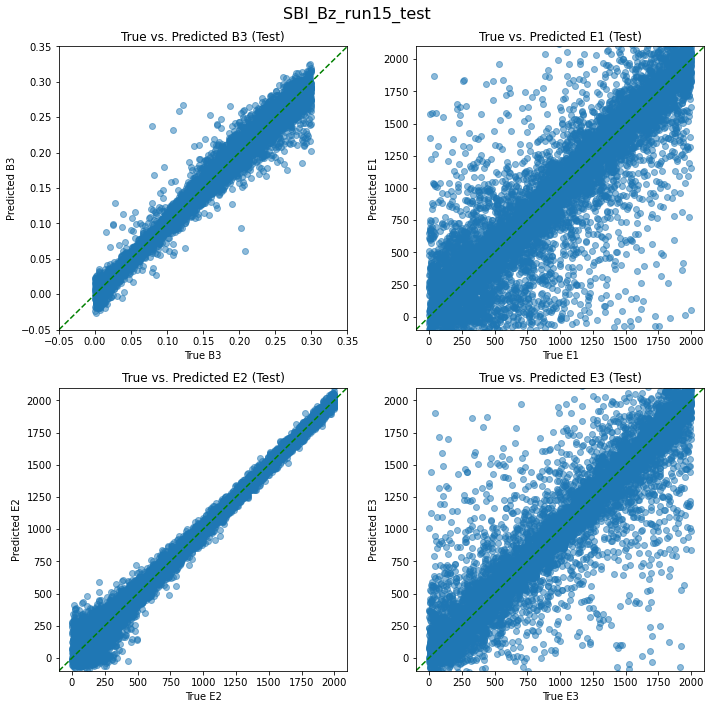

Testing set evaluation done.


In [143]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_test, B_pred_test, alpha=0.5)
plt.plot([-0.05, 1.1], [-0.05, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Test)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Test)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Test)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Test)')

plt.suptitle(f'{name_format}_test', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()


print("Testing set evaluation done.", flush=True)

